<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/ModelEvaluationMetrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score , precision_score
from sklearn.preprocessing import StandardScaler

In [22]:
from sklearn.datasets import load_breast_cancer, load_iris, load_wine

For data

In [23]:
data = [load_breast_cancer(), load_iris() ,load_wine()]
dataset_names = ['Breast Cancer' , 'Iris' , 'Wine']

In [24]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors= 6),
    'Decision Tree': DecisionTreeClassifier(criterion='gini' , max_depth = 7),
    'Random Forest': RandomForestClassifier(criterion = 'gini' , max_depth= None),
    'Support Vector Machine': SVC(kernel = 'rbf' , C= 1 , gamma = 'scale'),
    'Naive Bayes': GaussianNB()
}

In [30]:
results = []

In [31]:
for dataset_name , dataset in zip(dataset_names , data):
    X = dataset.data
    y = dataset.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test , y_pred , average = 'weighted')
        recall = recall_score(y_test, y_pred,average = 'weighted')
        f1 = f1_score(y_test, y_pred,average = 'weighted')
        results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })


In [32]:
results = pd.DataFrame(results)

In [33]:
results.head()

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Breast Cancer,Logistic Regression,0.973684,0.973719,0.973684,0.973621
1,Breast Cancer,K-Nearest Neighbors,0.956140,0.956488,0.956140,0.956237
2,Breast Cancer,Decision Tree,0.947368,0.947368,0.947368,0.947368
3,Breast Cancer,Random Forest,0.956140,0.956088,0.956140,0.956036
4,Breast Cancer,Support Vector Machine,0.982456,0.982937,0.982456,0.982369


In [71]:
from sklearn.metrics import RocCurveDisplay , ConfusionMatrixDisplay

In [72]:
colors = {'Breast Cancer': 'purple', 'Iris': 'yellow', 'Wine': 'violet'}

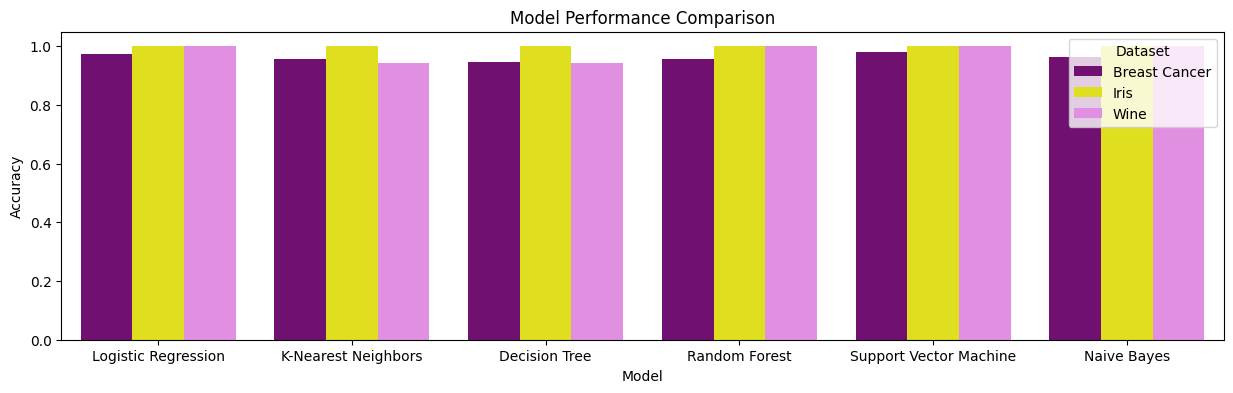

In [80]:
plt.figure(figsize=(15,4))
sns.barplot(data=results,x='Model', y='Accuracy',hue = 'Dataset',palette=colors)
plt.title('Model Performance Comparison')
plt.show()

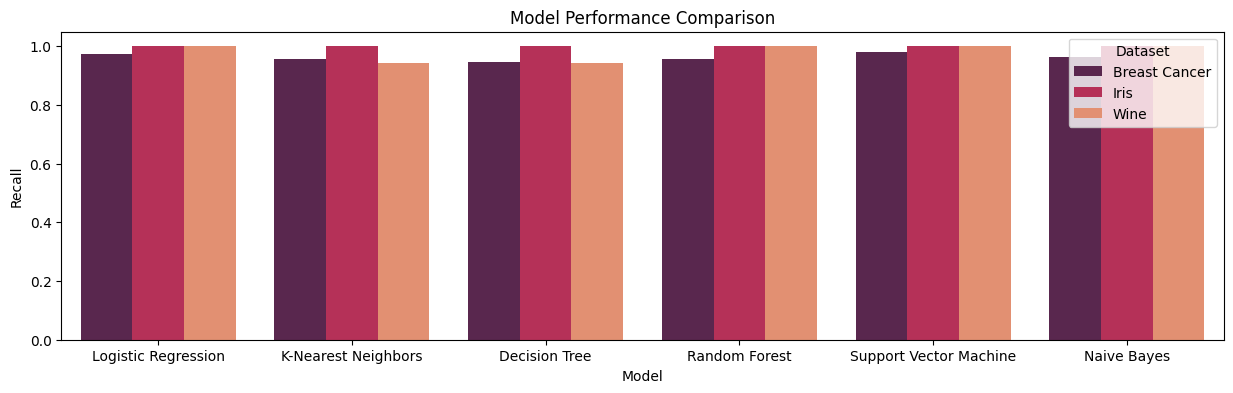

In [63]:
plt.figure(figsize=(15,4))
sns.barplot(data=results, x='Model', y='Recall',hue = 'Dataset',palette='rocket')
plt.title('Model Performance Comparison')
plt.show()

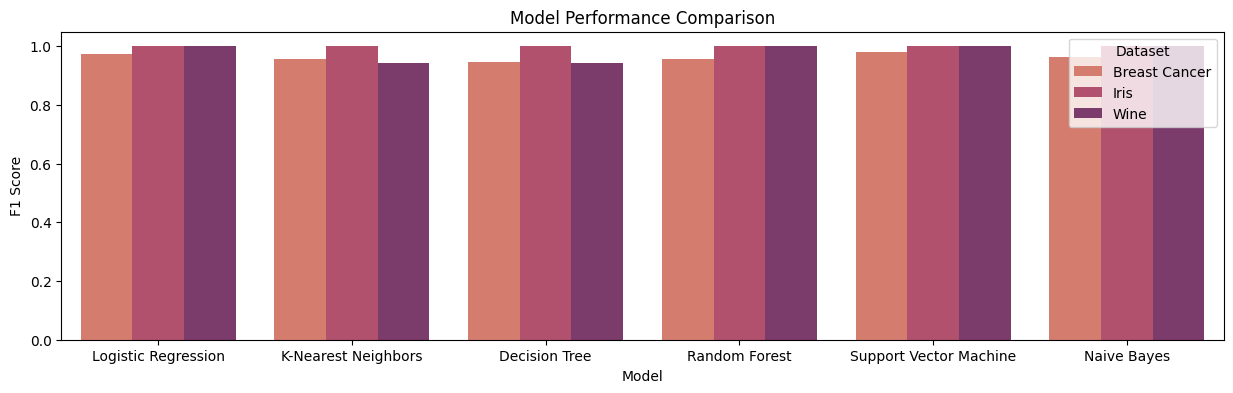

In [64]:
plt.figure(figsize=(15,4))
sns.barplot(data=results, x='Model', y='F1 Score',hue = 'Dataset',palette='flare')
plt.title('Model Performance Comparison')
plt.show()

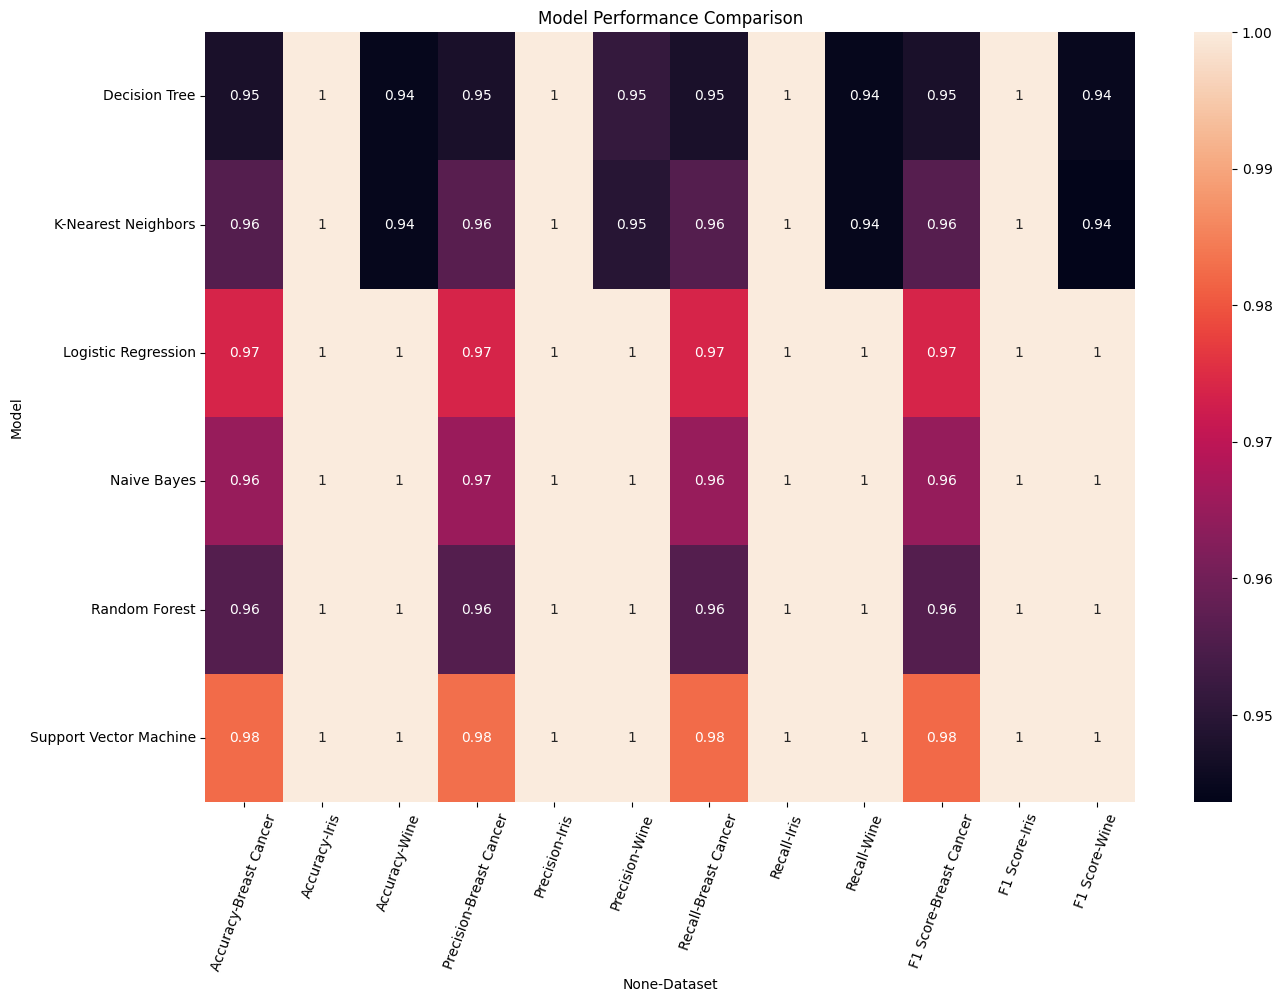

In [92]:
pivot = results.pivot(index='Model', columns='Dataset', values=['Accuracy','Precision','Recall','F1 Score'])
plt.figure(figsize=(15,10))
sns.heatmap(pivot , annot = True , cmap = 'rocket')
plt.title('Model Performance Comparison')
plt.xticks(rotation=70)
plt.show()